## Задачи для TensorFlow

In [ ]:
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import torch
from gensim.models import Word2Vec
from tensorflow.keras.layers import TextVectorization, LayerNormalization, Dropout, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import  accuracy_score, f1_score, roc_auc_score, roc_curve, auc
import numpy as np

import seaborn as sns
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.initializers import Constant

import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet') 

stop_words = set(stopwords.words('english'))

df = pd.read_csv('FakeNewsNet.csv')
df = df[['title', 'news_url', 'source_domain', 'real']]

# Проверка наличия пропущенных значений и удаление строк с пропущенными значениями
print(df.isnull().sum())
df.dropna(inplace=True)

print(df['real'].value_counts())

# Объединяем title, news_url и source_domain в один текстовый столбец
df['text'] = df['title'] + ' ' + df['news_url'] + ' ' + df['source_domain']
df = df[['text', 'real']]

# После объединения столбцов еще раз проверка пропущенных значений
print(df.isnull().sum())

# Количество элементов каждого класса
class_counts = df['real'].value_counts()

# Визуализация графика баланса классов
plt.figure(figsize=(6, 4))
sns.countplot(x='real', data=df, hue='real', palette='Set2', legend=False)
plt.title('Баланс классов')
plt.xlabel('Классы')
plt.ylabel('Количество элементов')
plt.show()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


title              0
news_url         330
source_domain    330
real               0
dtype: int64
real
1    17371
0     5495
Name: count, dtype: int64
text    0
real    0
dtype: int64


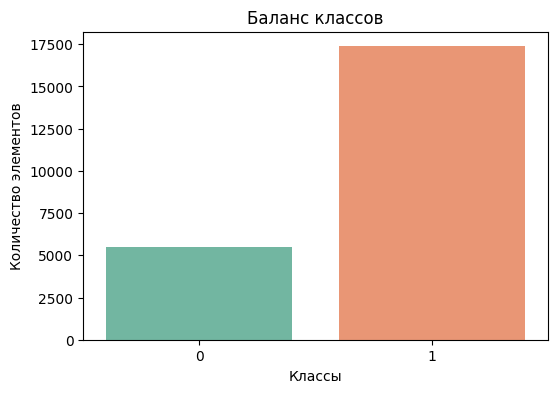

In [ ]:
def preprocess_text(text):
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.lower() not in stop_words]
    tokens = [word for word in tokens if word.isalpha()]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    preprocessed_text = ' '.join(tokens)
    return preprocessed_text

def preprocess_dataframe(dataframe, text_column):
    dataframe[text_column] = dataframe[text_column].apply(preprocess_text)
    return dataframe


# Предварительная обработка текстовых данных
df = preprocess_dataframe(df, 'text')

# Определение гиперпараметров
EMBEDDING_DIM = 256 
HIDDEN_DIM = 128    
OUTPUT_DIM = 1
N_EPOCHS = 20
BATCH = 8

# Разделение текста на предложения
sentences = df['text'].apply(lambda x: x.split())

def create_model(model_type):

  if model_type == 'RNN':
    model_layer = tf.keras.layers.RNN(tf.keras.layers.SimpleRNNCell(HIDDEN_DIM)) 
  elif model_type == 'LSTM':
    model_layer = tf.keras.layers.LSTM(HIDDEN_DIM)  
  elif model_type == 'GRU':
    model_layer = tf.keras.layers.GRU(HIDDEN_DIM)  
  else:
    raise ValueError(f"Unknown model type: {model_type}")

  model = tf.keras.Sequential([
      embedding_layer,
      model_layer,
      tf.keras.layers.Flatten(),
      tf.keras.layers.Dropout(0.2),
      LayerNormalization(), 
      Dense(OUTPUT_DIM, activation='sigmoid')
  ])
  model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
  return model 

# Определяем функцию для обучения модели и выведите на график результаты обучения
def train_and_plot(model_type, train_dataset, test_dataset, BATCH):
    print(model_type)
    model = create_model(model_type)
      
    # Используем early_stop, который прекращает обучение, когда validation loss больше не улучшается
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
    
    # Обучение модели
    history = model.fit(X_train, y_train, epochs=N_EPOCHS, validation_split=0.2, batch_size=BATCH, shuffle=True, callbacks=[early_stop])

    results = model.evaluate(test_dataset)
    print(f'{model_type} - Test Loss: {results[0]}, Test Accuracy: {results[1]}')

    history_dict = history.history
    
    acc = history_dict['accuracy']
    val_acc = history_dict['val_accuracy']
    loss = history_dict['loss']
    val_loss = history_dict['val_loss']
    epochs = history.epoch
    
    plt.figure(figsize=(6,4))
    plt.plot(epochs, loss, 'r', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss', size=10)
    plt.xlabel('Epochs', size=10)
    plt.ylabel('Loss', size=10)
    plt.legend(prop={'size': 10})
    plt.show()
    
    plt.figure(figsize=(6,4))
    plt.plot(epochs, acc, 'g', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy', size=10)
    plt.xlabel('Epochs', size=10)
    plt.ylabel('Accuracy', size=10)
    plt.legend(prop={'size': 10})
    plt.ylim((0.5,1))
    plt.show()

    # Оценка производительности модели
    y_pred = model.predict(X_test)

    # Преобразуем y_pred в бинарные значения (0 или 1)
    y_pred_binary = np.round(y_pred).astype(int) 
    y_pred_binary = np.array(y_pred_binary).flatten()

    accuracy = accuracy_score(y_test, y_pred_binary) 
    f1 = f1_score(y_test, y_pred_binary) 
    roc_auc = roc_auc_score(y_test, y_pred)
    
    print(f'{model_type} - Test Accuracy: {accuracy:.2f}, F1-Score: {f1:.2f}, AUC-ROC: {roc_auc:.2f}')

    # Строим ROC-кривую
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
    

In [2]:
w2v_model = Word2Vec(
                        sentences=sentences, 
                        vector_size=EMBEDDING_DIM, 
                        window=10, 
                        min_count=1, 
                        workers=8, 
                        negative=10,
                        alpha=0.03,
                        min_alpha=0.0007,
                        sample=6e-5,
                        sg=1, 
                        hs=1,
                        seed=42
                    )

w2v_model.build_vocab(sentences)  # Создание словаря модели
w2v_model.train(sentences, total_examples=w2v_model.corpus_count, epochs=15)  # Обучение модели на предложениях
w2v_model.save('w2v_model.txt')  # Сохранение обученной модели

# Загрузка обученной модели Word2Vec
w2v_model = Word2Vec.load('w2v_model.txt')

# Получение вложений слов
word2vec_vectors = w2v_model.wv

# Преобразование вложений слов в тензор TensorFlow
pre_trained_emb = tf.convert_to_tensor(word2vec_vectors.vectors, dtype=tf.float32)

# Добавление строки заполнения
padding_row = tf.zeros([1, EMBEDDING_DIM], dtype=tf.float32) 
pre_trained_emb = tf.concat([pre_trained_emb, padding_row], axis=0)

INPUT_DIM = len(word2vec_vectors.key_to_index) + 1

# Определение максимального размера словаря
max_size = len(w2v_model.wv.key_to_index)

# Создает словарь из num_words наиболее часто встречающихся слов в тексте.
tokenizer = Tokenizer(num_words=max_size)  # Используем max_size, чтобы сохранить все слова из Word2Vec
tokenizer.fit_on_texts(df['text'])

# Преобразует текст в последовательности целых чисел (индексы слов в словаре).
tokenized_text = tokenizer.texts_to_sequences(df['text'])

# Выравнивание последовательностей по длине (паддинг), для передачи в модель
maxlen = max(len(x) for x in tokenized_text)
padded_text = pad_sequences(tokenized_text, maxlen=maxlen)

# Создание Embedding-слоя
embedding_matrix = np.zeros((len(tokenizer.word_index) + 1, w2v_model.vector_size))  # Размер соответствует словарю Tokenizer

# Итерация по словарю "слово: индекс"
for word, i in tokenizer.word_index.items():
    # Если индекс превышает кол-во слов в словаре, то скипаем
    if i > tokenizer.num_words:
        continue
    # Проверяем, существует ли слово в словаре w2v_model.wv
    if word in w2v_model.wv:
        # Получаем вектор соответствущий слову в модели word2vec
        embedding_vector = w2v_model.wv[word]
        # Если слово найдено в словаре токенизатора, то в embedding_matrix проставляем вектор соответствующий слову
        embedding_matrix[i] = embedding_vector
    else:
        # Если слово не найдено, то можно использовать нулевой вектор
        embedding_matrix[i] = np.zeros(w2v_model.vector_size) 


# Embedding слой
embedding_layer = Embedding(
    # Размер словаря
    input_dim = len(tokenizer.word_index) + 1,  # Используем размер словаря Tokenizer
    # Размер вектора вложений
    output_dim = w2v_model.vector_size,
    # Установка весов слоя
    embeddings_initializer = Constant(embedding_matrix),
    # Длина входных последовательностей
    input_length = maxlen,
    # Предотвратит обновление весов во время обучения
    trainable = False
    )

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(padded_text, df['real'], test_size=0.20, random_state=42) 

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(BATCH)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH)
            

RNN
Epoch 1/20
1830/1830 [==============================] - 15s 7ms/step - loss: 0.4191 - accuracy: 0.8279 - val_loss: 0.4252 - val_accuracy: 0.8240
Epoch 2/20
1830/1830 [==============================] - 13s 7ms/step - loss: 0.3707 - accuracy: 0.8473 - val_loss: 0.3576 - val_accuracy: 0.8552
Epoch 3/20
1830/1830 [==============================] - 13s 7ms/step - loss: 0.3618 - accuracy: 0.8525 - val_loss: 0.3633 - val_accuracy: 0.8489
Epoch 4/20
1830/1830 [==============================] - 13s 7ms/step - loss: 0.3548 - accuracy: 0.8527 - val_loss: 0.3547 - val_accuracy: 0.8584
Epoch 5/20
1830/1830 [==============================] - 13s 7ms/step - loss: 0.3514 - accuracy: 0.8549 - val_loss: 0.3833 - val_accuracy: 0.8418
Epoch 6/20
1830/1830 [==============================] - 13s 7ms/step - loss: 0.3367 - accuracy: 0.8627 - val_loss: 0.3732 - val_accuracy: 0.8398
Epoch 7/20
1830/1830 [==============================] - 13s 7ms/step - loss: 0.3571 - accuracy: 0.8516 - val_loss: 0.3625 - va

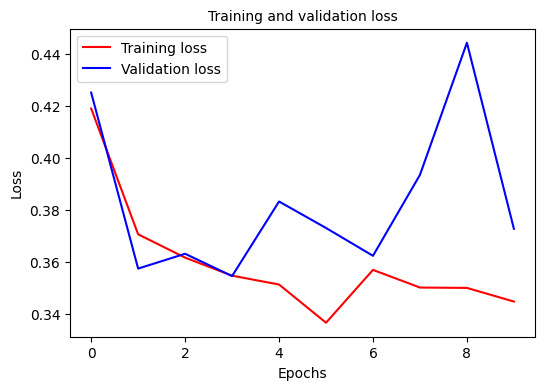

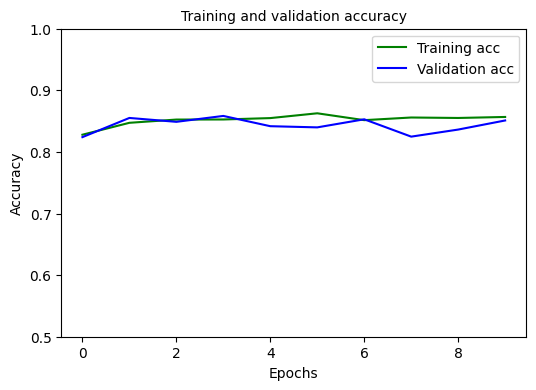

143/143 [==============================] - 1s 8ms/step
RNN - Test Accuracy: 0.8570179274158286, F1-Score: 0.9111413043478261, AUC-ROC: 0.8794663529203064


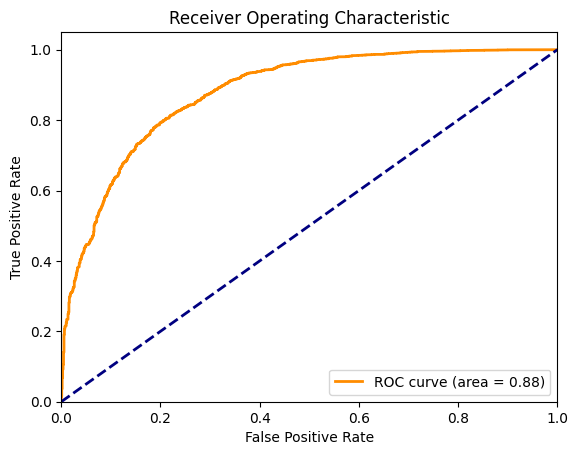

LSTM
Epoch 1/20
1830/1830 [==============================] - 41s 21ms/step - loss: 0.3833 - accuracy: 0.8402 - val_loss: 0.3453 - val_accuracy: 0.8568
Epoch 2/20
1830/1830 [==============================] - 35s 19ms/step - loss: 0.3256 - accuracy: 0.8657 - val_loss: 0.3317 - val_accuracy: 0.8655
Epoch 3/20
1830/1830 [==============================] - 34s 19ms/step - loss: 0.2889 - accuracy: 0.8814 - val_loss: 0.3439 - val_accuracy: 0.8650
Epoch 4/20
1830/1830 [==============================] - 35s 19ms/step - loss: 0.2469 - accuracy: 0.8973 - val_loss: 0.3662 - val_accuracy: 0.8628
Epoch 5/20
1830/1830 [==============================] - 35s 19ms/step - loss: 0.2048 - accuracy: 0.9140 - val_loss: 0.3899 - val_accuracy: 0.8598
Epoch 6/20
1830/1830 [==============================] - 36s 20ms/step - loss: 0.1590 - accuracy: 0.9371 - val_loss: 0.4478 - val_accuracy: 0.8595
Epoch 7/20
1830/1830 [==============================] - 38s 20ms/step - loss: 0.1183 - accuracy: 0.9529 - val_loss: 0.5

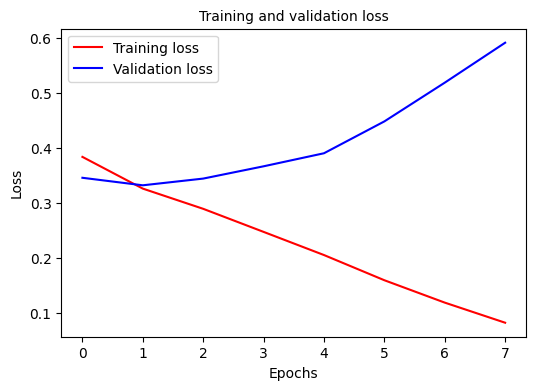

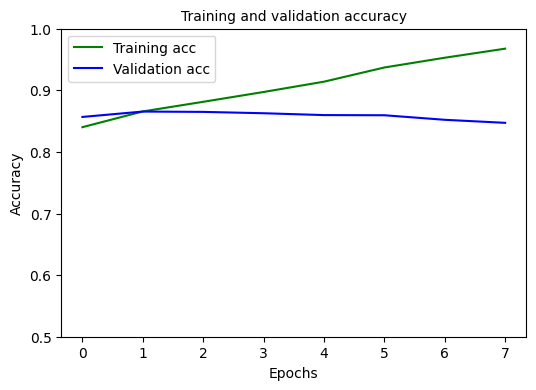

143/143 [==============================] - 2s 13ms/step
LSTM - Test Accuracy: 0.8635767380848273, F1-Score: 0.9120383422610657, AUC-ROC: 0.895127235540645


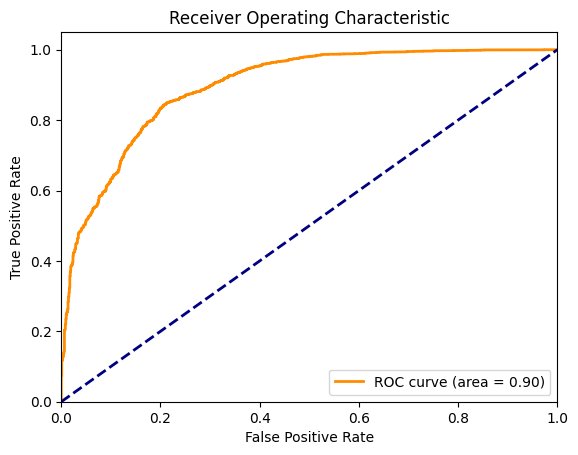

GRU
Epoch 1/20
1830/1830 [==============================] - 38s 19ms/step - loss: 0.3836 - accuracy: 0.8430 - val_loss: 0.3909 - val_accuracy: 0.8275
Epoch 2/20
1830/1830 [==============================] - 39s 21ms/step - loss: 0.3320 - accuracy: 0.8652 - val_loss: 0.3645 - val_accuracy: 0.8431
Epoch 3/20
1830/1830 [==============================] - 40s 22ms/step - loss: 0.3054 - accuracy: 0.8743 - val_loss: 0.3472 - val_accuracy: 0.8612
Epoch 4/20
1830/1830 [==============================] - 41s 22ms/step - loss: 0.2717 - accuracy: 0.8861 - val_loss: 0.3461 - val_accuracy: 0.8620
Epoch 5/20
1830/1830 [==============================] - 40s 22ms/step - loss: 0.2252 - accuracy: 0.9068 - val_loss: 0.3828 - val_accuracy: 0.8612
Epoch 6/20
1830/1830 [==============================] - 44s 24ms/step - loss: 0.1744 - accuracy: 0.9295 - val_loss: 0.4960 - val_accuracy: 0.8552
Epoch 7/20
1830/1830 [==============================] - 44s 24ms/step - loss: 0.1270 - accuracy: 0.9509 - val_loss: 0.53

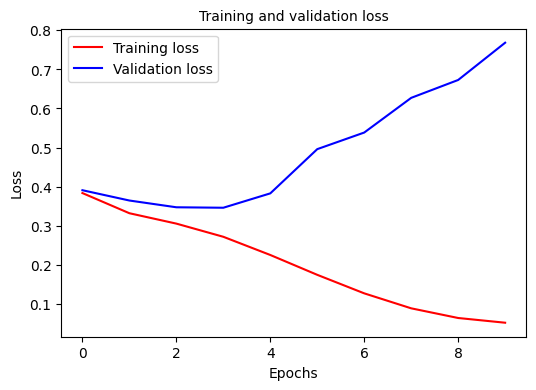

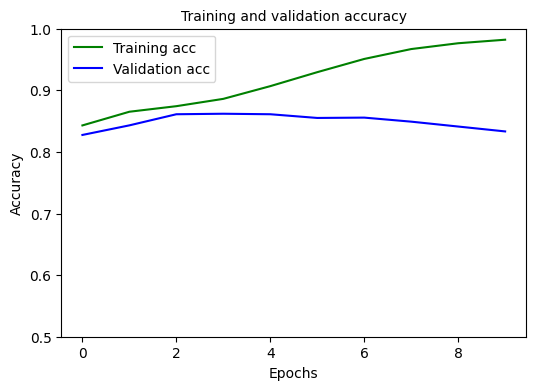

143/143 [==============================] - 2s 10ms/step
GRU - Test Accuracy: 0.8585483165719283, F1-Score: 0.9100264219162842, AUC-ROC: 0.8918042024446651


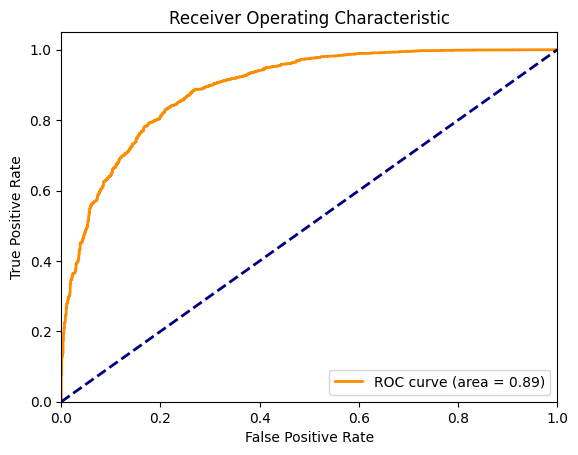

In [3]:
for model_type in ['RNN', 'LSTM', 'GRU']:
    train_and_plot(model_type, train_dataset, test_dataset, BATCH)